In [46]:
import pandas as pd
import numpy as np


In [47]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

# directory containing experiment folders
base_path = Path("./data")

# helper function to read CSV files
def load_csv(filepath):
    return pd.read_csv(filepath, header=None).values

# helper function: recursively find a file inside a folder
def find_file(root: Path, filename: str):
    return next(root.rglob(filename), None)

# data structure: {experiment_group: {calibration_folder: {translation, quaternion}}}
experiment_groups = {}

# iterate over each subdirectory of ./data (each is an experiment group)
for exp_group in sorted(base_path.iterdir()):
    if not exp_group.is_dir():
        continue

    experiment_groups[exp_group.name] = {}

    # walk through experiment group to find Calibration folders
    for path in exp_group.rglob("*"):
        if path.is_dir() and path.name.endswith("Calibration"):

            # recursively search inside Calibration folder
            trans_file = find_file(path, "translation_vector.csv")
            quat_file  = find_file(path, "rotation_quaternion.csv")

            if trans_file is not None and quat_file is not None:
                experiment_groups[exp_group.name][path.name] = {
                    "translation": load_csv(trans_file),
                    "quaternion": load_csv(quat_file),
                }

# display summary
print("Loaded experiment groups:")
for group, experiments in experiment_groups.items():
    print(f"  {group}: {len(experiments)} Calibration folders")


Loaded experiment groups:
  experiment_0_2Hz: 30 Calibration folders
  experiment_10Hz: 154 Calibration folders
  experiment_1Hz: 44 Calibration folders
  experiment_1HzNew: 114 Calibration folders
  experiment_2Hz: 0 Calibration folders
  experiment_5Hz: 130 Calibration folders


In [48]:
# Process each experiment group separately
for group_name, experiments in experiment_groups.items():
    print(f"\n{'='*50}")
    print(f"Experiment Group: {group_name}")
    print(f"{'='*50}")
    
    if not experiments:
        print("No Calibration folders found")
        continue
    
    # list of translation and rotation data for this group
    trans_list = []
    rot_list = []
    
    # populate lists
    for exp_name, data in experiments.items():
        trans_list.append(data["translation"])
        rot_list.append(data["quaternion"])
    
    # compute mean and stddev for translations
    trans_mean = np.mean(trans_list, axis=0)
    rot_mean = np.mean(rot_list, axis=0)
    trans_stddev = np.std(trans_list, axis=0)
    rot_stddev = np.std(rot_list, axis=0)
    
    # compute magnitudes
    translation_distance = np.linalg.norm(trans_mean)
    rotation_degree = np.linalg.norm(rot_mean) * (180.0 / np.pi)
    
    # compute mean of absolute sequential differences
    trans_magnitudes = [np.linalg.norm(t) for t in trans_list]
    trans_seq_diff_mean = 0.0
    if len(trans_magnitudes) > 1:
        trans_seq_diffs = [abs(trans_magnitudes[i+1] - trans_magnitudes[i]) for i in range(len(trans_magnitudes)-1)]
        trans_seq_diff_mean = np.mean(trans_seq_diffs)
    
    # display results for this group
    print(f"Number of Calibrations: {len(experiments)}")
    print(f"Mean Translation Magnitude (m): {translation_distance:.4f}")
    print(f"Mean Rotation Magnitude (degrees): {rotation_degree:.4f}")
    print(f"Mean Sequential Translation Difference (m): {trans_seq_diff_mean:.4f}")


Experiment Group: experiment_0_2Hz
Number of Calibrations: 30
Mean Translation Magnitude (m): 2.7258
Mean Rotation Magnitude (degrees): 56.5759
Mean Sequential Translation Difference (m): 0.1161

Experiment Group: experiment_10Hz
Number of Calibrations: 154
Mean Translation Magnitude (m): 1.4363
Mean Rotation Magnitude (degrees): 37.1951
Mean Sequential Translation Difference (m): 0.4086

Experiment Group: experiment_1Hz
Number of Calibrations: 44
Mean Translation Magnitude (m): 2.5055
Mean Rotation Magnitude (degrees): 56.8572
Mean Sequential Translation Difference (m): 0.1595

Experiment Group: experiment_1HzNew
Number of Calibrations: 114
Mean Translation Magnitude (m): 0.8784
Mean Rotation Magnitude (degrees): 41.8001
Mean Sequential Translation Difference (m): 0.0276

Experiment Group: experiment_2Hz
No Calibration folders found

Experiment Group: experiment_5Hz
Number of Calibrations: 130
Mean Translation Magnitude (m): 2.7556
Mean Rotation Magnitude (degrees): 57.1760
Mean Sequ

In [49]:
# iterate over each experiment group
for group_name, group_data in experiment_groups.items():
    # collect translations and quaternions for this group
    trans_list = []
    rot_list = []
    
    for calib in group_data.values():
        trans_list.append(calib["translation"])
        rot_list.append(calib["quaternion"])
    
    # convert to numpy arrays
    trans_array = np.array(trans_list)
    rot_array = np.array(rot_list)
    
    # compute mean and stddev
    trans_mean = np.mean(trans_array, axis=0)
    rot_mean = np.mean(rot_array, axis=0)
    trans_stddev = np.std(trans_array, axis=0)
    rot_stddev = np.std(rot_array, axis=0)
    
    # display results for this experiment group
    print(f"Experiment Group: {group_name}")
    print("  Mean Translation:\n", trans_mean)
    print("  Mean Quaternion:\n", rot_mean)
    print("  Translation StdDev:\n", trans_stddev)
    print("  Quaternion StdDev:\n", rot_stddev)
    print("-" * 50)


Experiment Group: experiment_0_2Hz
  Mean Translation:
 [[-1.86033238 -1.9920267  -0.03060316]]
  Mean Quaternion:
 [[ 0.00494304 -0.00414275  0.40717167  0.89955441]]
  Translation StdDev:
 [[0.51471751 0.22131751 0.13535406]]
  Quaternion StdDev:
 [[0.0206111  0.01939341 0.14582594 0.05390156]]
--------------------------------------------------
Experiment Group: experiment_10Hz
  Mean Translation:
 [[-0.41268014 -1.2773719   0.51074985]]
  Mean Quaternion:
 [[0.03549299 0.112411   0.20635529 0.60411319]]
  Translation StdDev:
 [[1.74899973 1.53956456 1.57985308]]
  Quaternion StdDev:
 [[0.31986946 0.34563776 0.35288705 0.48193107]]
--------------------------------------------------
Experiment Group: experiment_1Hz
  Mean Translation:
 [[-1.14845842 -2.22652091  0.03448689]]
  Mean Quaternion:
 [[0.01160697 0.00522983 0.17480909 0.97674463]]
  Translation StdDev:
 [[0.35639184 0.40866386 0.43801862]]
  Quaternion StdDev:
 [[0.06482933 0.06961576 0.07772763 0.01260348]]
---------------

c:\Projects\Uni\HapticGiantEvaluation\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Projects\Uni\HapticGiantEvaluation\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Projects\Uni\HapticGiantEvaluation\.venv\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Projects\Uni\HapticGiantEvaluation\.venv\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Projects\Uni\HapticGiantEvaluation\.venv\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [50]:
for group_name, group_data in experiment_groups.items():
    # collect translations and quaternions
    trans_list = []
    rot_list = []
    
    for calib in group_data.values():
        trans_list.append(calib["translation"])
        rot_list.append(calib["quaternion"])
    
    # convert to arrays
    trans_array = np.array(trans_list)
    rot_array = np.array(rot_list)
    
    # compute mean
    trans_mean = np.mean(trans_array, axis=0)
    rot_mean = np.mean(rot_array, axis=0)
    
    # compute distances/magnitudes
    translation_distance = np.linalg.norm(trans_mean)  # in whatever unit your CSV has
    rotation_degree = np.linalg.norm(rot_mean) * (180.0 / np.pi)  # radians → degrees
    
    # display
    print(f"Experiment Group: {group_name}")
    print("  Mean Translation Magnitude (m):", translation_distance)
    print("  Mean Rotation Magnitude (degrees):", rotation_degree)
    print("-" * 50)


Experiment Group: experiment_0_2Hz
  Mean Translation Magnitude (m): 2.725792266262116
  Mean Rotation Magnitude (degrees): 56.575876174026604
--------------------------------------------------
Experiment Group: experiment_10Hz
  Mean Translation Magnitude (m): 1.4362622578092505
  Mean Rotation Magnitude (degrees): 37.1951227716333
--------------------------------------------------
Experiment Group: experiment_1Hz
  Mean Translation Magnitude (m): 2.5055022366059574
  Mean Rotation Magnitude (degrees): 56.85723131264228
--------------------------------------------------
Experiment Group: experiment_1HzNew
  Mean Translation Magnitude (m): 0.8783908842767655
  Mean Rotation Magnitude (degrees): 41.80009191076105
--------------------------------------------------
Experiment Group: experiment_2Hz
  Mean Translation Magnitude (m): nan
  Mean Rotation Magnitude (degrees): nan
--------------------------------------------------
Experiment Group: experiment_5Hz
  Mean Translation Magnitude (m

In [51]:
for group_name, group_data in experiment_groups.items():
    # collect translations
    trans_list = [calib["translation"] for calib in group_data.values()]
    
    # convert to numpy arrays
    trans_array = np.array(trans_list)
    
    # mean translation
    trans_mean = np.mean(trans_array, axis=0)
    
    # translation magnitude
    translation_distance = np.linalg.norm(trans_mean)
    
    # compute sequential differences of magnitudes
    trans_magnitudes = [np.linalg.norm(t) for t in trans_list]
    
    if len(trans_magnitudes) > 1:
        trans_seq_diffs = [abs(trans_magnitudes[i+1] - trans_magnitudes[i])
                           for i in range(len(trans_magnitudes)-1)]
        trans_seq_diff_mean = np.mean(trans_seq_diffs)
    else:
        trans_seq_diff_mean = 0.0  # or np.nan if you prefer
    
    # display
    print(f"Experiment Group: {group_name}")
    print("  Mean Translation Magnitude (m):", translation_distance)
    print("  Mean of sequential absolute differences (m):", trans_seq_diff_mean)
    print("-" * 50)


Experiment Group: experiment_0_2Hz
  Mean Translation Magnitude (m): 2.725792266262116
  Mean of sequential absolute differences (m): 0.11611950485383676
--------------------------------------------------
Experiment Group: experiment_10Hz
  Mean Translation Magnitude (m): 1.4362622578092505
  Mean of sequential absolute differences (m): 0.4086266642997876
--------------------------------------------------
Experiment Group: experiment_1Hz
  Mean Translation Magnitude (m): 2.5055022366059574
  Mean of sequential absolute differences (m): 0.1595235012705353
--------------------------------------------------
Experiment Group: experiment_1HzNew
  Mean Translation Magnitude (m): 0.8783908842767655
  Mean of sequential absolute differences (m): 0.02756583649690193
--------------------------------------------------
Experiment Group: experiment_2Hz
  Mean Translation Magnitude (m): nan
  Mean of sequential absolute differences (m): 0.0
--------------------------------------------------
Experime

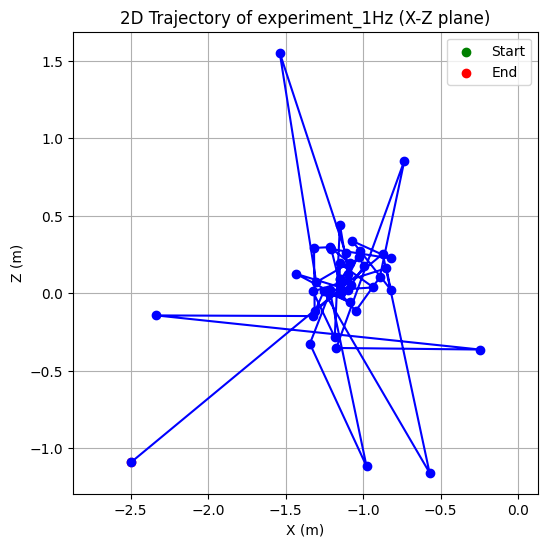

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Collect all translation vectors for a single experiment group
# Example: choose one group
group_name = "experiment_1Hz"  # replace with your actual group
group_data = experiment_groups[group_name]

# Extract translation vectors (3D points)
translations = [calib["translation"].flatten() for calib in group_data.values()]
translations = np.array(translations)  # shape: (N, 3)

# Choose 2D plane: X-Z plane (top view)
x = translations[:, 0]
z = translations[:, 2]

# Plot trajectory
plt.figure(figsize=(6, 6))
plt.plot(x, z, marker='o', linestyle='-', color='blue')
plt.scatter(x[0], z[0], color='green', label='Start')
plt.scatter(x[-1], z[-1], color='red', label='End')
plt.title(f"2D Trajectory of {group_name} (X-Z plane)")
plt.xlabel("X (m)")
plt.ylabel("Z (m)")
plt.grid(True)
plt.legend()
plt.axis('equal')  # keep aspect ratio 1:1
plt.show()
